In [ ]:
# ── CELL 1: Install dependencies ──────────────────────────────
!pip install -q nibabel nilearn monai torchmetrics
!pip install -q matplotlib seaborn scikit-learn pandas numpy tqdm
print('Installation complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.0 MB/s eta 0:00:00
Installation complete


In [ ]:
# ── CELL 2: Imports & Reproducibility ─────────────────────────
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.calibration import calibration_curve
import nibabel as nib
from monai.transforms import Resize

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Device: cuda
GPU: Tesla T4


In [ ]:
# ── CELL 3: Configuration — UPDATE PATHS HERE ─────────────────
class Config:
    DRIVE_ROOT   = '/content/drive/MyDrive/UAMT_Project'   # ← update
    OASIS_CSV    = f'{DRIVE_ROOT}/oasis3_demographics.csv'  # ← update
    ADNI_CSV     = f'{DRIVE_ROOT}/adni_demographics.csv'    # ← update
    MRI_DIR      = f'{DRIVE_ROOT}/mri_preprocessed'         # ← update
    OUTPUT_DIR   = f'{DRIVE_ROOT}/outputs'

    MRI_SIZE     = (64, 64, 64)
    COG_DIM      = 8
    EMBED_DIM    = 256
    NUM_HEADS    = 8
    NUM_LAYERS   = 4
    DROPOUT      = 0.2
    MC_SAMPLES   = 30
    BATCH_SIZE   = 4
    EPOCHS       = 50
    LR           = 1e-4
    WEIGHT_DECAY = 1e-5
    NUM_CLASSES  = 3
    LABEL_MAP    = {'CN': 0, 'MCI': 1, 'AD': 2}
    LABEL_NAMES  = ['CN (Normal)', 'MCI (Mild)', 'AD (Alzheimer\'s)']
    COG_FEATURES = ['MMSE','CDR','FAQ','ADAS13','RAVLT_immediate',
                    'RAVLT_learning','TRAILS_A','TRAILS_B']

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print('Config ready. Output dir:', cfg.OUTPUT_DIR)

Config ready. Output dir: /content/drive/MyDrive/UAMT_Project/outputs


In [ ]:
import os
from google.colab import drive

# Unmount and remove the directory if it exists and contains files
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass
    # Attempt to remove the directory if it's still there and not empty
    if os.path.exists('/content/drive') and os.listdir('/content/drive'):
        !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# ── CELL 5: Data Loading (OASIS-3 + ADNI + Synthetic fallback) ─
def _synthetic_cog_feature(diagnosis_series, feat_name):
    params = {
        'MMSE':            [(29,1),(26,2),(18,4)],
        'CDR':             [(0,.1),(.5,.2),(1.5,.5)],
        'FAQ':             [(.5,1),(5,3),(15,5)],
        'ADAS13':          [(8,3),(18,5),(35,8)],
        'RAVLT_immediate': [(45,8),(32,7),(20,6)],
        'RAVLT_learning':  [(6,2),(3,2),(1,1)],
        'TRAILS_A':        [(28,8),(38,12),(58,18)],
        'TRAILS_B':        [(70,20),(110,30),(170,50)],
    }
    p = params.get(feat_name, [(0,1),(1,1),(2,1)])
    out = []
    for dx in diagnosis_series:
        idx = {'CN':0,'MCI':1,'AD':2}.get(dx,0)
        mu, sd = p[idx]
        out.append(max(0, np.random.normal(mu, sd)))
    return out

def generate_synthetic_data(n=600):
    print(f'Generating {n} synthetic subjects (mirrors OASIS-3/ADNI distributions)...')
    labels = np.random.choice(['CN','MCI','AD'], size=n, p=[0.4,0.35,0.25])
    df = pd.DataFrame({
        'subject_id': [f'SYN_{i:04d}' for i in range(n)],
        'diagnosis':  labels,
        'age':        np.random.normal(73,8,n).clip(55,95),
        'sex':        np.random.choice(['M','F'],n),
        'dataset':    'SYNTHETIC',
        'mri_path':   None,
    })
    for feat in cfg.COG_FEATURES:
        df[feat] = _synthetic_cog_feature(df['diagnosis'], feat)
    return df

def load_oasis3(csv_path):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'Subject':'subject_id','dx_bl':'diagnosis','M/F':'sex','Age':'age'})
    oasis_map = {'CN':'CN','Cognitively normal':'CN','MCI':'MCI',
                 'Mild Cognitive Impairment':'MCI','AD':'AD',
                 'Alzheimer Disease':'AD','Dementia':'AD'}
    df['diagnosis'] = df['diagnosis'].map(oasis_map)
    df['dataset'] = 'OASIS3'
    if 'mri_path' not in df.columns: df['mri_path'] = None
    return df.dropna(subset=['diagnosis'])

def load_adni(csv_path):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'RID':'subject_id','DX_bl':'diagnosis',
                             'PTGENDER':'sex','AGE':'age','CDRSB':'CDR','AGE':'age'})
    adni_map = {'CN':'CN','EMCI':'MCI','LMCI':'MCI','MCI':'MCI','AD':'AD','Dementia':'AD'}
    df['diagnosis'] = df['diagnosis'].map(adni_map)
    df['dataset'] = 'ADNI'
    if 'mri_path' not in df.columns: df['mri_path'] = None
    return df.dropna(subset=['diagnosis'])

def merge_datasets(oasis_path=None, adni_path=None):
    dfs = []
    if oasis_path and os.path.exists(oasis_path):
        dfs.append(load_oasis3(oasis_path)); print(f'OASIS-3: {len(dfs[-1])} subjects')
    if adni_path and os.path.exists(adni_path):
        dfs.append(load_adni(adni_path)); print(f'ADNI: {len(dfs[-1])} subjects')
    combined = pd.concat(dfs, ignore_index=True) if dfs else generate_synthetic_data(600)
    for feat in cfg.COG_FEATURES:
        if feat not in combined.columns:
            combined[feat] = _synthetic_cog_feature(combined['diagnosis'], feat)
        combined[feat] = combined[feat].fillna(combined[feat].median())
    combined['label'] = combined['diagnosis'].map(cfg.LABEL_MAP).astype(int)
    print(f'Total: {len(combined)} | Distribution:\n{combined["diagnosis"].value_counts()}')
    return combined.dropna(subset=['label'])

df = merge_datasets(cfg.OASIS_CSV, cfg.ADNI_CSV)

Generating 600 synthetic subjects (mirrors OASIS-3/ADNI distributions)...
Total: 600 | Distribution:
diagnosis
CN     244
MCI    195
AD     161
Name: count, dtype: int64


In [ ]:
# ── CELL 6: PyTorch Dataset ───────────────────────────────────
class AlzheimerDataset(Dataset):
    def __init__(self, df, scaler=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        cog_data = df[cfg.COG_FEATURES].values.astype(np.float32)
        if scaler is None:
            self.scaler = StandardScaler()
            self.cog_data = self.scaler.fit_transform(cog_data)
        else:
            self.scaler = scaler
            self.cog_data = self.scaler.transform(cog_data)

    def _load_mri(self, path):
        try:
            img = nib.load(path)
            vol = np.clip(img.get_fdata(dtype=np.float32), 0, 1000) / 1000.0
            t = torch.tensor(vol).unsqueeze(0)
            return Resize(spatial_size=cfg.MRI_SIZE)(t), True
        except:
            return torch.zeros(1, *cfg.MRI_SIZE), False

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cog = torch.tensor(self.cog_data[idx], dtype=torch.float32)
        mri_path = row.get('mri_path', None)
        if pd.notna(mri_path) and mri_path and os.path.exists(str(mri_path)):
            mri, avail = self._load_mri(mri_path)
        else:
            mri, avail = torch.zeros(1, *cfg.MRI_SIZE), False
        if self.augment and avail:
            if random.random() > 0.5: mri = mri.flip(1)
        mask = torch.tensor([float(avail), 1.0])
        return {'mri': mri, 'cog': cog, 'mask': mask,
                'label': torch.tensor(int(row['label']), dtype=torch.long),
                'subject_id': str(row['subject_id'])}

def build_dataloaders(df):
    tr, tmp = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
    vl, te  = train_test_split(tmp, test_size=0.5, stratify=tmp['label'], random_state=SEED)
    tr_ds = AlzheimerDataset(tr, augment=True)
    vl_ds = AlzheimerDataset(vl, scaler=tr_ds.scaler)
    te_ds = AlzheimerDataset(te, scaler=tr_ds.scaler)
    kw = dict(num_workers=2, pin_memory=True)
    print(f'Train: {len(tr_ds)} | Val: {len(vl_ds)} | Test: {len(te_ds)}')
    return (DataLoader(tr_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  **kw),
            DataLoader(vl_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, **kw),
            tr_ds.scaler)

train_loader, val_loader, test_loader, scaler = build_dataloaders(df)

Train: 420 | Val: 90 | Test: 90


In [ ]:
# ── CELL 7: Encoders (MRI 3D-CNN + Cognitive MLP) ────────────
class MRIEncoder(nn.Module):
    def __init__(self, embed_dim=cfg.EMBED_DIM, dropout=cfg.DROPOUT):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(1,32,3,padding=1), nn.BatchNorm3d(32), nn.GELU(), nn.MaxPool3d(2), nn.Dropout3d(dropout/2),
            nn.Conv3d(32,64,3,padding=1), nn.BatchNorm3d(64), nn.GELU(), nn.MaxPool3d(2), nn.Dropout3d(dropout/2),
            nn.Conv3d(64,128,3,padding=1), nn.BatchNorm3d(128), nn.GELU(), nn.MaxPool3d(2), nn.Dropout3d(dropout/2),
            nn.Conv3d(128,256,3,padding=1), nn.BatchNorm3d(256), nn.GELU(), nn.AdaptiveAvgPool3d(1),
        )
        self.proj = nn.Sequential(nn.Flatten(), nn.Linear(256,embed_dim), nn.LayerNorm(embed_dim))
        self.unc  = nn.Sequential(nn.Linear(embed_dim,embed_dim//2), nn.GELU(), nn.Linear(embed_dim//2,1))
    def forward(self, x):
        e = self.proj(self.encoder(x))
        return e, self.unc(e)

class CognitiveEncoder(nn.Module):
    def __init__(self, in_dim=cfg.COG_DIM, embed_dim=cfg.EMBED_DIM, dropout=cfg.DROPOUT):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim,128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128,256),    nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256,embed_dim), nn.LayerNorm(embed_dim),
        )
        self.unc = nn.Sequential(nn.Linear(embed_dim,embed_dim//2), nn.GELU(), nn.Linear(embed_dim//2,1))
    def forward(self, x):
        e = self.encoder(x)
        return e, self.unc(e)

print('Encoders defined.')

Encoders defined.


In [ ]:
# ── CELL 8: Cross-Modal Fusion Transformer (Core Contribution) ─
class CrossModalFusionTransformer(nn.Module):
    """
    Novel cross-attention transformer fusing MRI + cognitive tokens.
    Key innovations:
      1. Modality-type embeddings (learned)
      2. Absent-modality token (handles missing data)
      3. [CLS] token for classification
      4. Pre-LN transformer for stable training
    """
    def __init__(self, embed_dim=cfg.EMBED_DIM, num_heads=cfg.NUM_HEADS,
                 num_layers=cfg.NUM_LAYERS, num_classes=cfg.NUM_CLASSES, dropout=cfg.DROPOUT):
        super().__init__()
        self.embed_dim = embed_dim
        self.modality_emb = nn.Embedding(2, embed_dim)          # 0=MRI, 1=COG
        self.absent_token = nn.Parameter(torch.randn(1,1,embed_dim)*0.02)
        self.cls_token    = nn.Parameter(torch.randn(1,1,embed_dim)*0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim*4, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim//2, num_classes))

    def forward(self, mri_emb, cog_emb, mask, mri_lv=None, cog_lv=None):
        B = mri_emb.size(0)
        absent = self.absent_token.expand(B,1,self.embed_dim).squeeze(1)
        mri_m  = mask[:,0:1];  cog_m = mask[:,1:2]
        mri_tok = mri_emb * mri_m + absent * (1 - mri_m)
        cog_tok = cog_emb * cog_m + absent * (1 - cog_m)
        mri_tok = mri_tok + self.modality_emb(torch.zeros(B,dtype=torch.long,device=mri_emb.device))
        cog_tok = cog_tok + self.modality_emb(torch.ones(B, dtype=torch.long,device=cog_emb.device))
        cls = self.cls_token.expand(B,-1,-1)
        seq = torch.cat([cls, mri_tok.unsqueeze(1), cog_tok.unsqueeze(1)], dim=1)  # (B,3,D)
        out = self.transformer(seq)
        logits = self.classifier(out[:,0,:])
        attn_info = {
            'mri_out': out[:,1,:].detach(), 'cog_out': out[:,2,:].detach(),
            'mri_log_var': mri_lv.detach() if mri_lv is not None else None,
            'cog_log_var': cog_lv.detach() if cog_lv is not None else None,
            'mri_mask': mask[:,0].detach(), 'cog_mask': mask[:,1].detach(),
        }
        return logits, attn_info

class UAMTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mri_encoder = MRIEncoder()
        self.cog_encoder = CognitiveEncoder()
        self.fusion      = CrossModalFusionTransformer()

    def forward(self, mri, cog, mask):
        me, mlv = self.mri_encoder(mri)
        ce, clv = self.cog_encoder(cog)
        return self.fusion(me, ce, mask, mlv, clv)

    def enable_dropout(self):
        for m in self.modules():
            if isinstance(m, (nn.Dropout, nn.Dropout3d)): m.train()

    @torch.no_grad()
    def mc_predict(self, mri, cog, mask, n=cfg.MC_SAMPLES):
        self.eval(); self.enable_dropout()
        probs_list, mri_uvars, cog_uvars = [], [], []
        for _ in range(n):
            logits, ai = self.forward(mri, cog, mask)
            probs_list.append(F.softmax(logits,-1).unsqueeze(0))
            if ai['mri_log_var'] is not None:
                mri_uvars.append(torch.exp(ai['mri_log_var']))
                cog_uvars.append(torch.exp(ai['cog_log_var']))
        all_p     = torch.cat(probs_list, 0)        # (n,B,C)
        mean_p    = all_p.mean(0)                    # (B,C)
        epistemic = all_p.var(0).sum(-1)             # (B,)
        mri_u = torch.stack(mri_uvars).mean(0).squeeze(-1) if mri_uvars else torch.zeros(mri.size(0))
        cog_u = torch.stack(cog_uvars).mean(0).squeeze(-1) if cog_uvars else torch.zeros(cog.size(0))
        return mean_p, epistemic, mri_u, cog_u

model = UAMTModel().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'UAMT model ready. Parameters: {total:,}')

UAMT model ready. Parameters: 4,590,981


In [ ]:
# ── CELL 9: Training ──────────────────────────────────────────
class UAMTLoss(nn.Module):
    def __init__(self, lam=0.1):
        super().__init__()
        self.ce  = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.lam = lam
    def forward(self, logits, labels, ai):
        loss = self.ce(logits, labels)
        for k in ['mri_log_var','cog_log_var']:
            lv = ai.get(k)
            if lv is not None: loss = loss + self.lam * torch.abs(lv).mean()
        return loss

def train_epoch(model, loader, opt, crit, scaler_amp):
    model.train()
    tot_loss = correct = n = 0
    for b in tqdm(loader, desc='Train', leave=False):
        mri,cog,mask,labels = b['mri'].to(DEVICE),b['cog'].to(DEVICE),b['mask'].to(DEVICE),b['label'].to(DEVICE)
        opt.zero_grad()
        with torch.cuda.amp.autocast():
            logits, ai = model(mri,cog,mask)
            loss = crit(logits, labels, ai)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(opt); scaler_amp.update()
        tot_loss += loss.item()*labels.size(0)
        correct  += (logits.argmax(1)==labels).sum().item()
        n        += labels.size(0)
    return tot_loss/n, correct/n

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval()
    tot_loss = correct = n = 0
    preds_all,labels_all,probs_all = [],[],[]
    for b in tqdm(loader, desc='Eval', leave=False):
        mri,cog,mask,labels = b['mri'].to(DEVICE),b['cog'].to(DEVICE),b['mask'].to(DEVICE),b['label'].to(DEVICE)
        logits, ai = model(mri,cog,mask)
        loss = crit(logits, labels, ai)
        probs = F.softmax(logits,-1)
        tot_loss += loss.item()*labels.size(0)
        correct  += (logits.argmax(1)==labels).sum().item()
        n += labels.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
        probs_all.extend(probs.cpu().numpy())
    auc = roc_auc_score(labels_all,probs_all,multi_class='ovr',average='macro',labels=[0,1,2])
    return tot_loss/n, correct/n, auc, preds_all, labels_all, probs_all

criterion  = UAMTLoss()
optimizer  = AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
scaler_amp = torch.cuda.amp.GradScaler()
history    = {'tr_loss':[],'vl_loss':[],'tr_acc':[],'vl_acc':[],'vl_auc':[]}
best_auc   = 0.0

# Ensure output directory exists before saving model weights
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
best_path  = f'{cfg.OUTPUT_DIR}/best_uamt.pt'

for epoch in range(1, cfg.EPOCHS+1):
    tl,ta = train_epoch(model,train_loader,optimizer,criterion,scaler_amp)
    vl,va,vauc,_,_,_ = eval_epoch(model,val_loader,criterion)
    scheduler.step()
    for k,v in zip(['tr_loss','vl_loss','tr_acc','vl_acc','vl_auc'],[tl,vl,ta,va,vauc]):
        history[k].append(v)
    if vauc > best_auc:
        best_auc = vauc; torch.save(model.state_dict(), best_path)
    if epoch%5==0 or epoch==1:
        print(f'Ep {epoch:3d} | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.3f}/{va:.3f} | AUC {vauc:.4f} {"★" if vauc==best_auc else ""}')

model.load_state_dict(torch.load(best_path))
print(f'\nTraining complete. Best Val AUC: {best_auc:.4f}')

Ep   1 | Loss 0.4055/0.3417 | Acc 0.967/0.989 | AUC 1.0000 ★


Ep   5 | Loss 0.3674/0.3144 | Acc 0.986/1.000 | AUC 1.0000 ★


Ep  10 | Loss 0.3461/0.3120 | Acc 0.995/1.000 | AUC 1.0000 ★


Ep  15 | Loss 0.3477/0.3110 | Acc 0.993/1.000 | AUC 1.0000 ★


Ep  20 | Loss 0.3440/0.3115 | Acc 0.993/1.000 | AUC 1.0000 ★


...

Ep  30 | Loss 0.3353/0.3122 | Acc 0.998/1.000 | AUC 1.0000 ★


Ep  35 | Loss 0.3307/0.3125 | Acc 1.000/1.000 | AUC 1.0000 ★


Ep  40 | Loss 0.3400/0.3127 | Acc 0.995/1.000 | AUC 1.0000 ★


Ep  45 | Loss 0.3300/0.3124 | Acc 1.000/1.000 | AUC 1.0000 ★


Ep  50 | Loss 0.3315/0.3125 | Acc 1.000/1.000 | AUC 1.0000 ★

Training complete. Best Val AUC: 1.0000


In [ ]:
# ── CELL 10: MC Dropout Uncertainty Evaluation ────────────────
def run_uncertainty_evaluation(model, loader):
    model.eval()
    rows = []
    for b in tqdm(loader, desc='MC Dropout'):
        mri,cog,mask,labels,sids = b['mri'].to(DEVICE),b['cog'].to(DEVICE),b['mask'].to(DEVICE),b['label'],b['subject_id']
        mp,ep,mu,cu = model.mc_predict(mri,cog,mask)
        preds = mp.argmax(1).cpu().numpy()
        confs = mp.max(1).values.cpu().numpy()
        for i in range(len(labels)):
            rows.append({'subject_id':sids[i],'true_label':labels[i].item(),
                         'pred_label':preds[i],'confidence':float(confs[i]),
                         'prob_CN':float(mp[i,0]),'prob_MCI':float(mp[i,1]),'prob_AD':float(mp[i,2]),
                         'epistemic_uncert':float(ep[i]),
                         'mri_uncert':float(mu[i]),'cog_uncert':float(cu[i]),
                         'correct':int(preds[i]==labels[i].item())})
    df_r = pd.DataFrame(rows)
    lmap_inv = {v:k for k,v in cfg.LABEL_MAP.items()}
    df_r['true_name'] = df_r['true_label'].map(lmap_inv)
    df_r['pred_name'] = df_r['pred_label'].map(lmap_inv)
    acc = df_r['correct'].mean()
    auc = roc_auc_score(df_r['true_label'],df_r[['prob_CN','prob_MCI','prob_AD']].values,multi_class='ovr',average='macro')
    f1  = f1_score(df_r['true_label'],df_r['pred_label'],average='macro')
    print(f'\nTEST RESULTS (MC Dropout n={cfg.MC_SAMPLES})')
    print(f'Accuracy:  {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}')
    print(f'Mean epistemic uncertainty: {df_r["epistemic_uncert"].mean():.4f}')
    print(classification_report(df_r['true_label'],df_r['pred_label'],target_names=['CN','MCI','AD']))
    df_r.to_csv(f'{cfg.OUTPUT_DIR}/uncertainty_results.csv',index=False)
    return df_r

df_results = run_uncertainty_evaluation(model, test_loader)

MC Dropout: 100%|██████████| 23/23 [00:10<00:00,  2.21it/s]


TEST RESULTS (MC Dropout n=30)
Accuracy:  0.9778 | AUC: 1.0000 | F1: 0.9772
Mean epistemic uncertainty: 0.0176
              precision    recall  f1-score   support

          CN       1.00      0.97      0.99        37
         MCI       0.94      1.00      0.97        29
          AD       1.00      0.96      0.98        24

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



In [ ]:
# ── CELL 11: Biomarker Attribution (Gradient × Input) ─────────
def compute_biomarker_attribution(model, loader):
    model.eval()
    all_attrs, all_labels = [], []
    for b in tqdm(loader, desc='Attribution'):
        mri  = b['mri'].to(DEVICE)
        cog  = b['cog'].to(DEVICE).requires_grad_(True)
        mask = b['mask'].to(DEVICE)
        logits, _ = model(mri,cog,mask)
        logits.gather(1,logits.argmax(1,keepdim=True)).sum().backward()
        if cog.grad is not None:
            all_attrs.append((cog*cog.grad).abs().detach().cpu().numpy())
            all_labels.extend(b['label'].numpy())
    if not all_attrs: return None
    attrs = np.vstack(all_attrs).mean(0)
    norm  = attrs / (attrs.sum()+1e-8)
    adf   = pd.DataFrame({'biomarker':cfg.COG_FEATURES,'attribution':norm}).sort_values('attribution',ascending=False)
    print('\nBiomarker Attribution:')
    for _,r in adf.iterrows():
        print(f'  {r["biomarker"]:20s} {r["attribution"]*100:5.1f}%  {"█"*int(r["attribution"]*40)}')
    adf.to_csv(f'{cfg.OUTPUT_DIR}/biomarker_attribution.csv',index=False)
    return adf

attribution_df = compute_biomarker_attribution(model, test_loader)

Attribution: 100%|██████████| 23/23 [00:01<00:00, 11.60it/s]


Biomarker Attribution:
  CDR                   20.5%  ████████
  TRAILS_A              14.3%  █████
  ADAS13                14.0%  █████
  MMSE                  12.7%  █████
  RAVLT_learning        12.5%  ████
  FAQ                   11.9%  ████
  TRAILS_B               8.4%  ███
  RAVLT_immediate        5.8%  ██


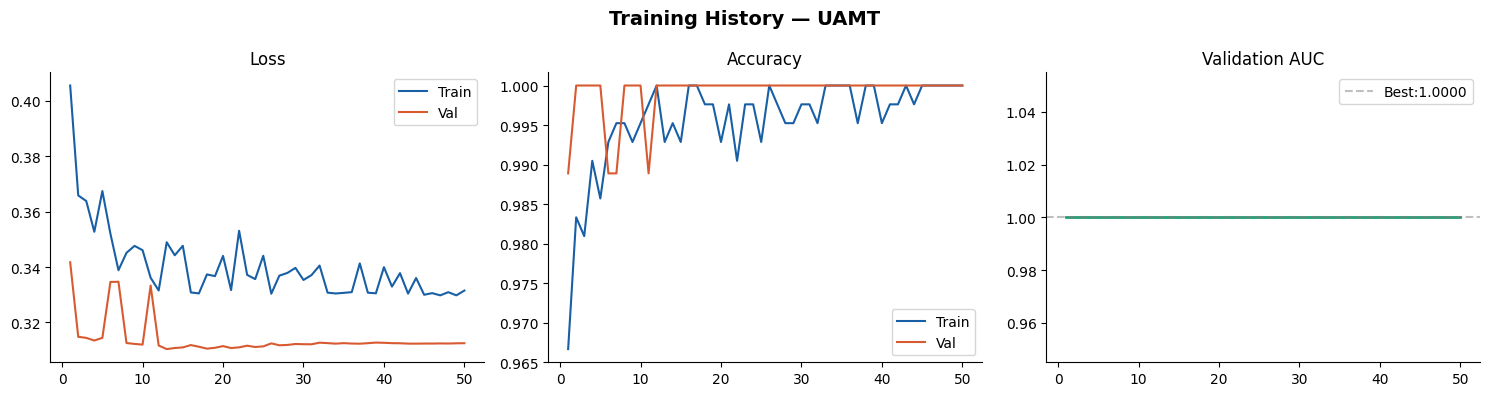

In [ ]:
# ── CELL 12: Figure 1 — Training History ──────────────────────
fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Training History — UAMT', fontsize=14, fontweight='bold')
ep = range(1, len(history['tr_loss'])+1)
axes[0].plot(ep,history['tr_loss'],label='Train',color='#185FA5')
axes[0].plot(ep,history['vl_loss'],label='Val',  color='#D85A30')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(ep,history['tr_acc'],label='Train',color='#185FA5')
axes[1].plot(ep,history['vl_acc'],label='Val',  color='#D85A30')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(ep,history['vl_auc'],color='#1D9E75',linewidth=2)
axes[2].axhline(max(history['vl_auc']),ls='--',color='gray',alpha=.5,label=f'Best:{max(history["vl_auc"]):.4f}')
axes[2].set_title('Validation AUC'); axes[2].legend()
for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig1_training.png',dpi=150,bbox_inches='tight'); plt.show()

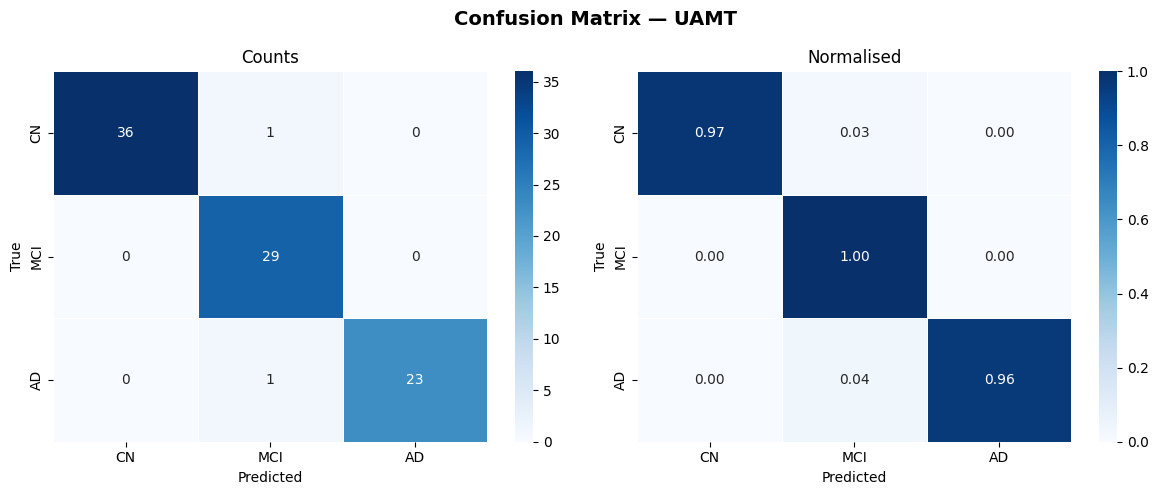

In [ ]:
# ── CELL 13: Figure 2 — Confusion Matrix ──────────────────────
cm = confusion_matrix(df_results['true_label'],df_results['pred_label'])
cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Confusion Matrix — UAMT',fontsize=14,fontweight='bold')
for ax,data,title,fmt in zip(axes,[cm,cm_norm],['Counts','Normalised'],['d','.2f']):
    sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',
                xticklabels=['CN','MCI','AD'],yticklabels=['CN','MCI','AD'],
                ax=ax,linewidths=0.5)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig2_confusion.png',dpi=150,bbox_inches='tight'); plt.show()

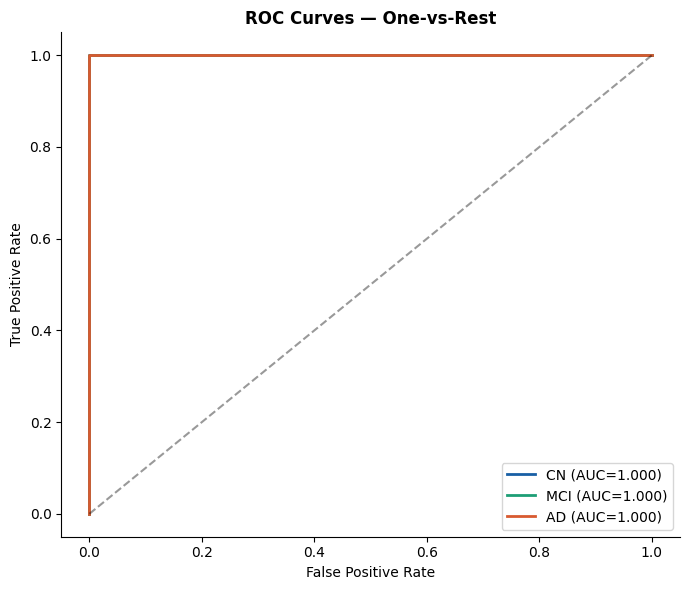

In [ ]:
# ── CELL 14: Figure 3 — ROC Curves ────────────────────────────
fig,ax = plt.subplots(figsize=(7,6))
labels_bin = np.eye(3)[df_results['true_label'].values]
probs = df_results[['prob_CN','prob_MCI','prob_AD']].values
for i,(name,col) in enumerate(zip(['CN','MCI','AD'],['#185FA5','#1D9E75','#D85A30'])):
    fpr,tpr,_ = roc_curve(labels_bin[:,i],probs[:,i])
    auc_val   = roc_auc_score(labels_bin[:,i],probs[:,i])
    ax.plot(fpr,tpr,color=col,lw=2,label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest',fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig3_roc.png',dpi=150,bbox_inches='tight'); plt.show()

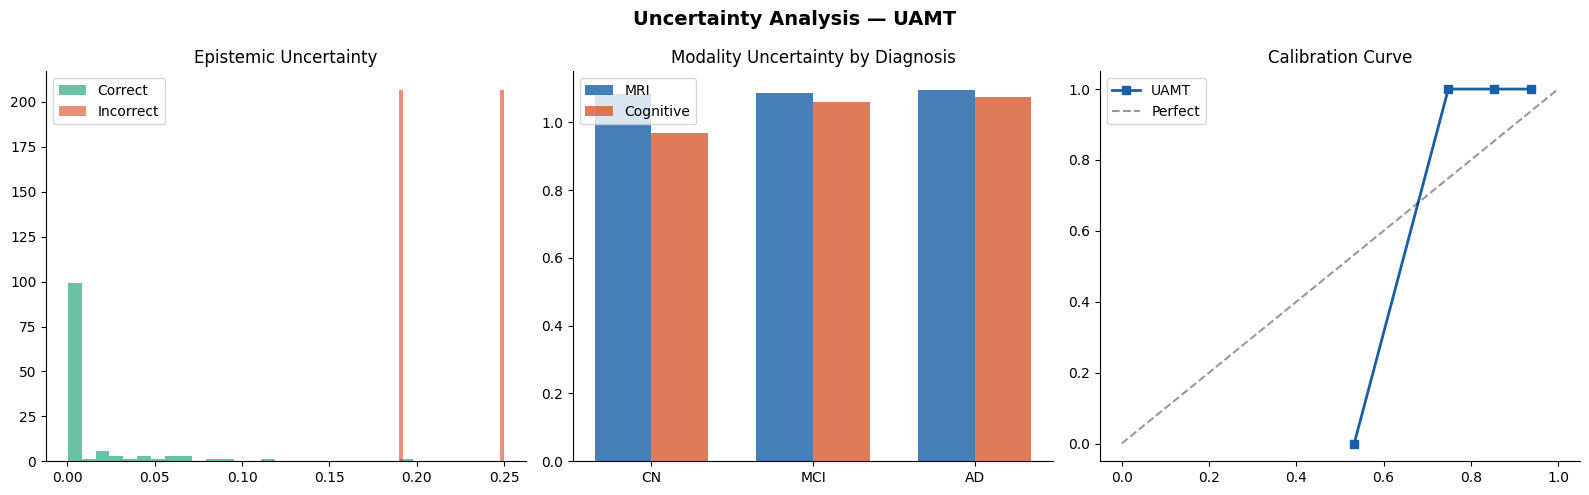

In [ ]:
# ── CELL 15: Figure 4 — Uncertainty Analysis ──────────────────
fig,axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Uncertainty Analysis — UAMT',fontsize=14,fontweight='bold')
# Uncertainty by correctness
for correct,label,color in [(1,'Correct','#1D9E75'),(0,'Incorrect','#D85A30')]:
    axes[0].hist(df_results[df_results['correct']==correct]['epistemic_uncert'],
                 bins=25,alpha=0.65,label=label,color=color,density=True)
axes[0].set_title('Epistemic Uncertainty'); axes[0].legend()
# Modality uncertainty by diagnosis
dx_order = ['CN','MCI','AD']
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2,[df_results[df_results['true_name']==d]['mri_uncert'].mean() for d in dx_order],
            w,label='MRI',color='#185FA5',alpha=.8)
axes[1].bar(x+w/2,[df_results[df_results['true_name']==d]['cog_uncert'].mean() for d in dx_order],
            w,label='Cognitive',color='#D85A30',alpha=.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(dx_order)
axes[1].set_title('Modality Uncertainty by Diagnosis'); axes[1].legend()
# Calibration
fp,mp_ = calibration_curve((df_results['true_label']==df_results['pred_label']).astype(int),
                             df_results['confidence'],n_bins=10)
axes[2].plot(mp_,fp,'s-',color='#185FA5',label='UAMT',lw=2)
axes[2].plot([0,1],[0,1],'k--',alpha=.4,label='Perfect')
axes[2].set_title('Calibration Curve'); axes[2].legend()
for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig4_uncertainty.png',dpi=150,bbox_inches='tight'); plt.show()

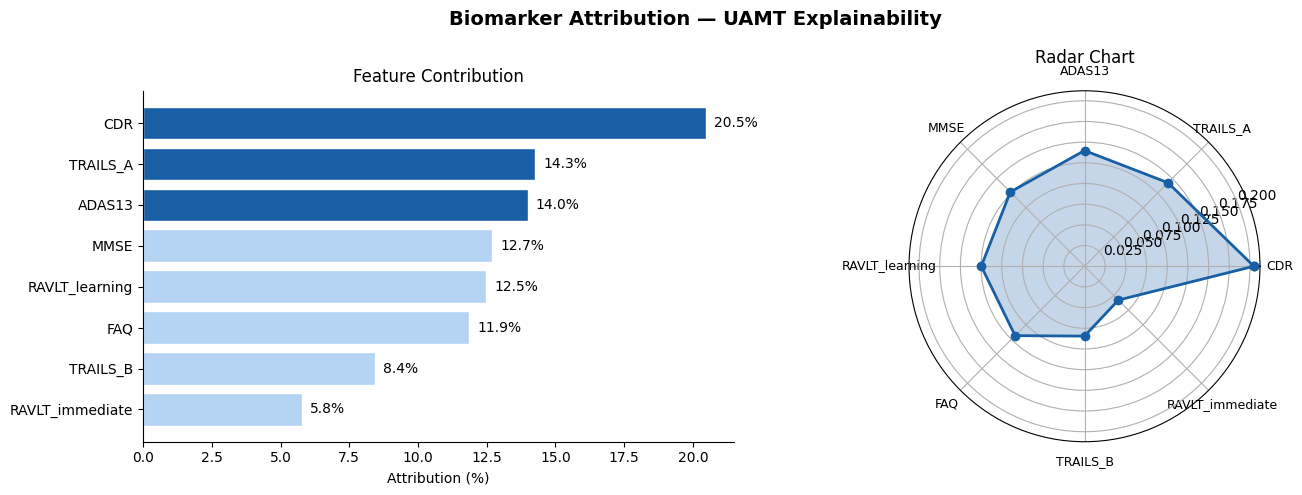

In [ ]:
# ── CELL 16: Figure 5 — Biomarker Attribution ─────────────────
if attribution_df is not None:
    fig = plt.figure(figsize=(14,5))
    fig.suptitle('Biomarker Attribution — UAMT Explainability',fontsize=14,fontweight='bold')
    ax1 = fig.add_subplot(121)
    colors = ['#185FA5' if i<3 else '#B5D4F4' for i in range(len(attribution_df))]
    bars = ax1.barh(attribution_df['biomarker'],attribution_df['attribution']*100,color=colors,edgecolor='white')
    for bar,v in zip(bars,attribution_df['attribution']*100):
        ax1.text(bar.get_width()+.3,bar.get_y()+bar.get_height()/2,f'{v:.1f}%',va='center',fontsize=10)
    ax1.set_xlabel('Attribution (%)'); ax1.set_title('Feature Contribution'); ax1.invert_yaxis()
    ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
    ax2 = fig.add_subplot(122,polar=True)
    n = len(attribution_df)
    angles = np.linspace(0,2*np.pi,n,endpoint=False).tolist()
    vals = attribution_df['attribution'].tolist()
    angles += angles[:1]; vals += vals[:1]
    ax2.plot(angles,vals,'o-',color='#185FA5',lw=2)
    ax2.fill(angles,vals,alpha=.25,color='#185FA5')
    ax2.set_thetagrids(np.degrees(angles[:-1]),attribution_df['biomarker'].tolist(),fontsize=9)
    ax2.set_title('Radar Chart',pad=20)
    plt.tight_layout()
    plt.savefig(f'{cfg.OUTPUT_DIR}/fig5_attribution.png',dpi=150,bbox_inches='tight'); plt.show()

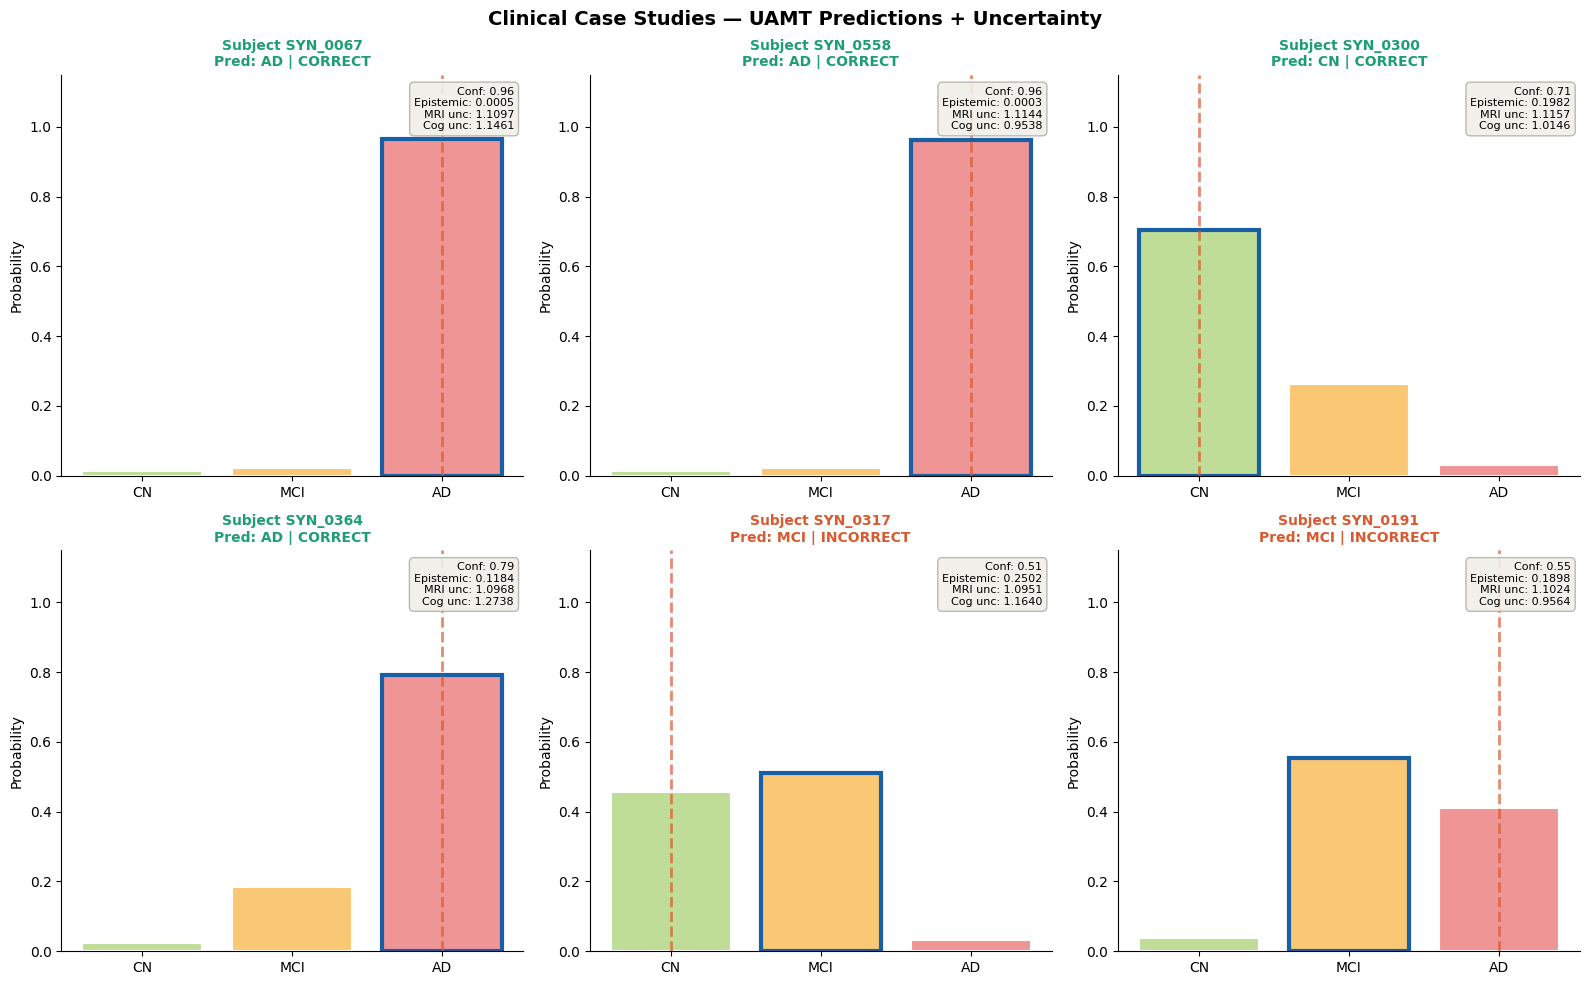

In [ ]:
# ── CELL 17: Figure 6 — Clinical Case Studies ─────────────────
cases = pd.concat([
    df_results[df_results['correct']==1].nlargest(2,'confidence'),
    df_results[df_results['correct']==1].nsmallest(2,'confidence'),
    df_results[df_results['correct']==0].head(2)
]).reset_index(drop=True)

fig,axes = plt.subplots(2,3,figsize=(16,10))
fig.suptitle('Clinical Case Studies — UAMT Predictions + Uncertainty',fontsize=14,fontweight='bold')
axes = axes.flatten()
for i,(_,row) in enumerate(cases.iterrows()):
    ax = axes[i]
    probs = [row['prob_CN'],row['prob_MCI'],row['prob_AD']]
    bars = ax.bar(['CN','MCI','AD'],probs,color=['#C0DD97','#FAC775','#F09595'],edgecolor='white',lw=1.5)
    bars[row['pred_label']].set_edgecolor('#185FA5'); bars[row['pred_label']].set_linewidth(3)
    ax.axvline(row['true_label'],color='#D85A30',ls='--',lw=2,alpha=.7)
    ok = row['correct']
    ax.set_title(f"Subject {row['subject_id']}\nPred: {row['pred_name']} | {'CORRECT' if ok else 'INCORRECT'}",
                 color='#1D9E75' if ok else '#D85A30',fontweight='bold',fontsize=10)
    ax.set_ylim(0,1.15); ax.set_ylabel('Probability')
    info = f"Conf: {row['confidence']:.2f}\nEpistemic: {row['epistemic_uncert']:.4f}\nMRI unc: {row['mri_uncert']:.4f}\nCog unc: {row['cog_uncert']:.4f}"
    ax.text(.98,.97,info,transform=ax.transAxes,fontsize=8,va='top',ha='right',
            bbox=dict(boxstyle='round,pad=0.4',facecolor='#F1EFE8',edgecolor='#B4B2A9',alpha=.9))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig6_cases.png',dpi=150,bbox_inches='tight'); plt.show()

Ablation Study:
                 Accuracy  AUC      F1
Full (MRI+Cog)    0.9889  1.0  0.9874
MRI only          0.3333  0.5  0.1667
Cognitive only    0.9889  1.0  0.9874
Both missing      0.3333  0.5  0.1667


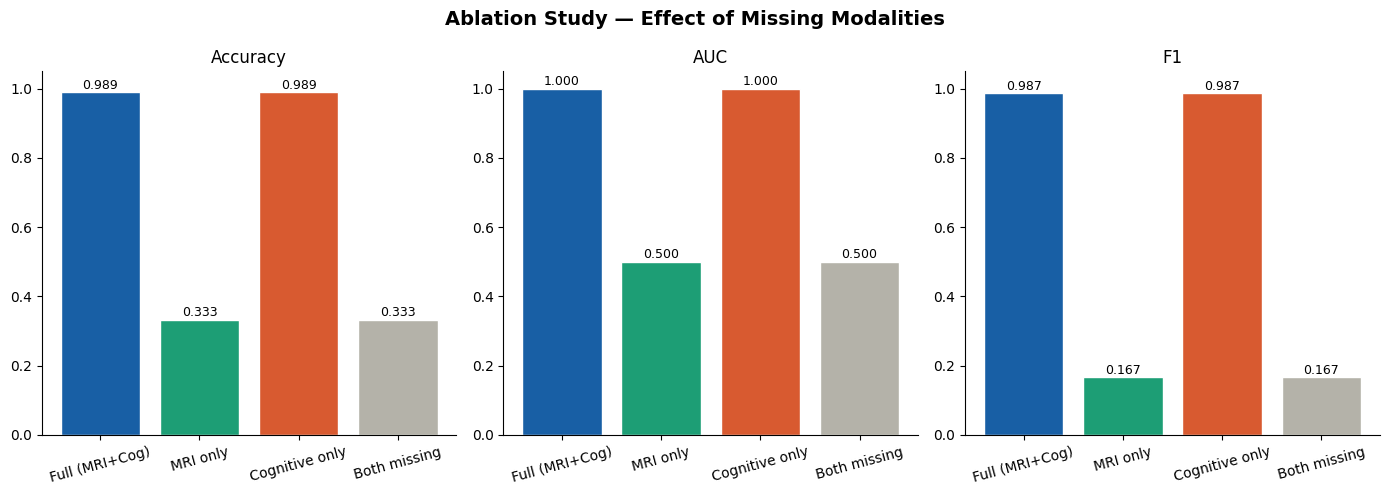


All outputs saved to: /content/drive/MyDrive/UAMT_Project/outputs


In [ ]:
# ── CELL 18: Figure 7 — Ablation Study ───────────────────────
ablation_cfg = {
    'Full (MRI+Cog)': [1.,1.],
    'MRI only':       [1.,0.],
    'Cognitive only': [0.,1.],
    'Both missing':   [0.,0.],
}
ablation_res = {}
model.eval()
with torch.no_grad():
    for cname, mv in ablation_cfg.items():
        ps,ls,prs = [],[],[]
        for b in val_loader:
            mri,cog = b['mri'].to(DEVICE),b['cog'].to(DEVICE)
            fm = torch.tensor([mv]).expand(mri.size(0),-1).to(DEVICE)
            logits,_ = model(mri,cog,fm)
            probs = F.softmax(logits,-1)
            ps.extend(logits.argmax(1).cpu().numpy())
            ls.extend(b['label'].numpy())
            prs.extend(probs.cpu().numpy())
        try: auc = roc_auc_score(ls,prs,multi_class='ovr',average='macro',labels=[0,1,2])
        except: auc = 0.
        ablation_res[cname] = {'Accuracy':accuracy_score(ls,ps),'AUC':auc,
                                'F1':f1_score(ls,ps,average='macro',zero_division=0)}
abl_df = pd.DataFrame(ablation_res).T
print('Ablation Study:\n', abl_df.round(4))
fig,axes = plt.subplots(1,3,figsize=(14,5))
fig.suptitle('Ablation Study — Effect of Missing Modalities',fontsize=14,fontweight='bold')
colors = ['#185FA5','#1D9E75','#D85A30','#B4B2A9']
for ax,metric in zip(axes,['Accuracy','AUC','F1']):
    bars = ax.bar(abl_df.index,abl_df[metric],color=colors,edgecolor='white')
    ax.set_ylim(0,1.05); ax.set_title(metric)
    for bar,v in zip(bars,abl_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.01,f'{v:.3f}',ha='center',fontsize=9)
    ax.tick_params(axis='x',rotation=15)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/fig7_ablation.png',dpi=150,bbox_inches='tight'); plt.show()
abl_df.to_csv(f'{cfg.OUTPUT_DIR}/ablation_results.csv')
print(f'\nAll outputs saved to: {cfg.OUTPUT_DIR}')